In [2]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [12]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]


    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/P_o[i]
        gamma.append(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

def simulate_vals_const(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50, const=0):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]


    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/P_o[i]
        gamma.append(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i] + Decimal(const)
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [4]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

const = Decimal(0)

beta = Decimal(23)

delta_e = Decimal(50)

In [18]:
# Generating synthetic curve for comparison
D_init = Decimal(1000)
P_init = Decimal(9.e5)
E_init = Decimal(1e5)

D_e = simulate_vals(D_init=D_init,
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]

D_e = np.array([float(str(x)) for x in D_e])


# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)
# curve -= curve[0] #NOTE THAT WE ARE SHIFTING THE CURVE DOWN !!! NEED TO ADDRESS LATER


def func_to_optimize(params):
    tried_params.append(params)
    
    D_e_cur = simulate_vals(D_init=Decimal(10**params[0]),
                        E_init=Decimal(10**params[1]), 
                        P_init=Decimal(10**params[2]), 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]
    D_e_cur = np.array([float(str(x)) for x in D_e_cur])
    return ((curve - D_e_cur)**2).mean()

def func_to_optimize_const(params):
    tried_params.append(params)
    
    D_e_cur = simulate_vals_const(D_init=Decimal(10**params[0]),
                        E_init=Decimal(10**params[1]), 
                        P_init=Decimal(10**params[2]), 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44,
                        const = params[3])[2]
    D_e_cur = np.array([float(str(x)) for x in D_e_cur]) + params[3]
    return ((curve - D_e_cur)**2).mean()
        

In [27]:
from scipy.optimize import minimize

init_params = np.array([4, 6, 5])
tried_params = []

res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-2, 'disp': True})
print(tried_params)
print(10**res.x)

Optimization terminated successfully.
         Current function value: 4757167349.584823
         Iterations: 127
         Function evaluations: 230
[array([4., 6., 5.]), array([4.2, 6. , 5. ]), array([4. , 6.3, 5. ]), array([4.  , 6.  , 5.25]), array([4.13333333, 5.7       , 5.16666667]), array([4.22222222, 5.8       , 5.27777778]), array([4.33333333, 5.7       , 5.41666667]), array([4.11111111, 5.6       , 5.55555556]), array([4.06666667, 5.4       , 5.83333333]), array([4.13333333, 5.7       , 5.83333333]), array([4.35555556, 5.2       , 6.13888889]), array([4.08888889, 5.8       , 5.47222222]), array([3.85925926, 5.56666667, 6.00925926]), array([3.95061728, 5.31111111, 6.3117284 ]), array([4.05432099, 5.67777778, 5.68209877]), array([4.31028807, 5.61851852, 5.55658436]), array([3.97201646, 5.57962963, 5.89609053]), array([4.06035665, 5.44197531, 6.02640604]), array([4.0558299 , 5.61882716, 5.76817558]), array([4.05884774, 5.50092593, 5.94032922]), array([4.05658436, 5.58935185, 5.8

[Decimal('2.3487278590303493075452934135682880878448486328125'), Decimal('4.697392941128555212634708907'), Decimal('9.394534789409974137554013549'), Decimal('18.78806532646355045631197859'), Decimal('37.57211459544918570896557337'), Decimal('75.12817257161982934174841659'), Decimal('150.1921794721376543168686273'), Decimal('300.1281814469426768324950116'), Decimal('599.2355143463313965499491757'), Decimal('1194.418208997680161956575632'), Decimal('2372.864782230336426520577384'), Decimal('4683.684557138983917280912314'), Decimal('9132.817071373909434142384428'), Decimal('17421.57693718884115914710546'), Decimal('32045.80037880500775542447692'), Decimal('55884.50410452459898049792635'), Decimal('91130.32910791170296147060539'), Decimal('138236.0427317921555182638555'), Decimal('195767.5465795215624376491793'), Decimal('261082.7415049601850941605968'), Decimal('331142.8096377191284197081028'), Decimal('403060.4350275977492486052017'), Decimal('474369.0096682170623754355270'), Decimal('54

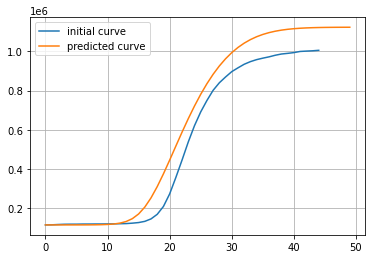

In [31]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=delta_e,
                    n_d=n_d,
                    n_dE=n_dE,
                    k_C=k_C,
                    beta=beta,
                    n_cycle=49)[2]

print(D_e_pred)

D_e_pred = np.array(D_e_pred) + Decimal(curve[0])

plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()

In [25]:
from scipy.optimize import minimize

print(Decimal(curve[0]))

init_params = np.array([4, 6, 5, 5])
tried_params = []

res = minimize(func_to_optimize_const, init_params, method='nelder-mead', options={'xatol': 1e-2, 'disp': True})
print(tried_params)
print(10**res.x)

113397.830000000001746229827404022216796875
[array([4., 6., 5., 5.]), array([4.2, 6. , 5. , 5. ]), array([4. , 6.3, 5. , 5. ]), array([4.  , 6.  , 5.25, 5.  ]), array([4.  , 6.  , 5.  , 5.25]), array([4.1  , 5.7  , 5.125, 5.125]), array([4.15  , 5.85  , 5.1875, 5.1875]), array([4.225  , 5.775  , 5.28125, 4.90625]), array([4.3375  , 5.6625  , 5.421875, 4.734375]), array([4.09375  , 5.60625  , 5.4921875, 5.0234375]), array([4.040625  , 5.409375  , 5.73828125, 5.03515625]), array([4.1640625 , 5.7609375 , 5.67382812, 4.85351562]), array([4.12109375, 5.56640625, 5.85449219, 4.62402344]), array([4.10664062, 5.42460937, 6.18798828, 4.34228516]), array([4.33164062, 5.19960937, 6.09423828, 4.62353516]), array([4.08291016, 5.79990234, 5.46105957, 4.90588379]), array([3.8668457 , 5.60581055, 5.94195557, 4.97491455]), array([4.01340332, 5.3713623 , 6.14321899, 4.83792114]), array([4.06553345, 5.69276733, 5.63159943, 4.88889313]), array([4.03078003, 5.47849731, 5.97267914, 4.8549118 ]), array([3.86

2.000297311652428


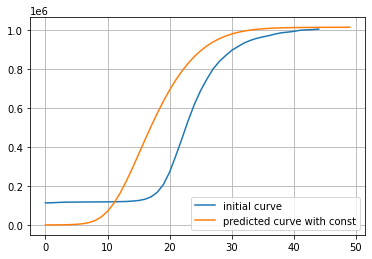

In [26]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals_const(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=delta_e,
                    n_d=n_d,
                    n_dE=n_dE,
                    k_C=k_C,
                    beta=beta,
                    n_cycle=49,
                    const =Decimal(10**res.x[3]))[2]

plt.plot(D_e_pred, label = 'predicted curve with const')
plt.legend()
plt.grid()

print(res.x[3])